# python for stock trading


##### this ducument explains how to import stock's data from YAHOO, choose the best market to invest in, calculate you portfolio, and other intersting things.

In [1]:
import yfinance
import mplfinance as mpf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
from matplotlib import pyplot as plt
import seaborn as sns
from plotly import express as px
import datetime as dt
import os

pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = 1000
pd.options.display.max_columns = 1000

sns.set()

### Library Imports
In this section, we import libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`, `plotly`, `mplfinance`), and financial data retrieval (`yfinance`). We also import `scipy.stats` and `statsmodels` for performing regression and statistical analysis.


# downloading Data From YAHOO!

In [2]:
stocknames = ['AAPL', 'MSFT', 'TSLA', 'GC=F', 'SPY']
startdate = '2025-01-01'
enddate = dt.datetime.now().date()
interval = '1d'

In [3]:
for stock in stocknames:
    df = yfinance.download(stock, start=startdate, end=enddate, interval=interval, auto_adjust=False, actions=False)
    df.reset_index(inplace=True)
    df.to_csv('{}.csv'.format(stock), index=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Data Retrieval
We use the `yfinance` API to download historical market data. For each ticker in our list, we fetch the data and save it as a CSV file for local access. This ensures we have a persistent copy of the data.


In [4]:
def appnding(cols = [], startdate='', enddate=''):
    global df
    dates = pd.date_range(start=startdate, end=enddate)
    df = pd.DataFrame(index=dates)
    
    for stock in stocknames:
        df_symbols = pd.read_csv('{}.csv'.format(stock), index_col='Date', parse_dates=True, usecols=cols, na_values=['NAN'])
        df_symbols = df_symbols.rename(columns={'Adj Close': stock})
        df = df.join(df_symbols)
    
    df = df.dropna()
    return df

In [5]:
appnding(['Date', 'Adj Close'], startdate, enddate)
df.index.names = ['Date']
df = df.rename(columns={'GC=F':'gold', 'AAPL' : 'aapl', 'MSFT' : 'msft', 'TSLA' : 'tsla', 'SPY':'spy'})
df.head()

,aapl,msft,tsla,gold,spy
Date,,,,,
2025-01-02,242.3019256591797,413.672607421875,379.2799987792969,2658.89990234375,576.2802734375
2025-01-03,241.81504821777344,418.3866882324219,410.44000244140625,2645.0,583.4857788085938
2025-01-06,243.44461059570312,422.8339538574219,411.04998779296875,2638.39990234375,586.8471069335938
2025-01-07,240.67233276367188,417.418212890625,394.3599853515625,2656.699951171875,580.2132568359375
2025-01-08,241.15919494628906,419.5824890136719,394.94000244140625,2664.5,581.0609130859375


### Data Consolidation
The `appnding` function aligns the 'Adj Close' prices for all tickers into a single DataFrame based on a common date index. Renaming columns to lowercase and descriptive names (e.g., 'gold' for 'GC=F') makes the code cleaner and more intuitive.


## GLOBAL STATISTICS

In [6]:
df = df.astype(float)
df_desc = df.describe().T
df_desc = df_desc[['count', 'mean', 'std', '50%', 'max']]
df_desc

,count,mean,std,50%,max
aapl,348.00,241.24,28.61,243.92,308.82
msft,348.00,447.38,50.78,449.06,538.66
tsla,348.00,370.26,64.62,382.33,489.88
gold,348.00,"3,828.52",741.05,"3,646.55","5,318.40"
spy,348.00,635.80,54.79,645.91,748.17


### Summary Statistics
Descriptive statistics provide a quick overview of the price levels. The `mean` shows the average price, while the `std` (standard deviation) indicates the historical volatility of the asset's price.


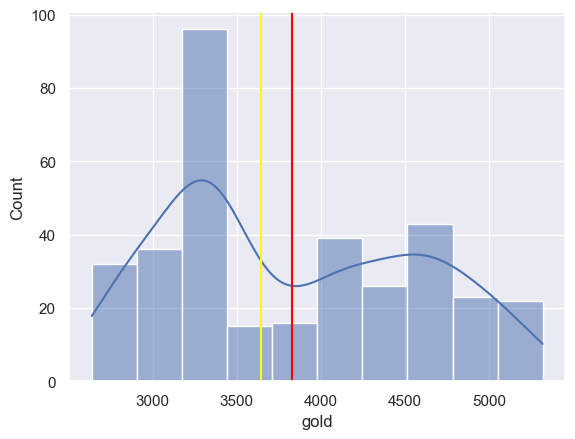

In [7]:
sns.histplot(data=df, x='gold', kde=True)
plt.axvline(df.gold.mean(), color="red")
plt.axvline(df.gold.median(), color="yellow")

In [8]:
px.line(data_frame=df, title='tickers adj. close price')

### Price Visualization
Visualizing the raw adjusted close prices allows us to see the absolute price trends. However, because different stocks have different price ranges, it can be difficult to compare their relative performance at a glance.


### normalizing

In [9]:
norm = df / df.iloc[0,:]
fig = px.line(norm)
fig.update_layout(title='stack movement observation by normalizing adj close prices , (daily cumulative return)',
                   xaxis_title='Date', 
                   yaxis_title='Normalized price')
fig.show()

### Normalization and Cumulative Returns
By dividing every price by the first price in the series, we 'normalize' the data so all assets start at 1.0. This makes it easy to compare the percentage growth of different stocks (e.g., Apple vs. Tesla) over the same period regardless of their starting price.


<Axes: xlabel='tsla', ylabel='Count'>

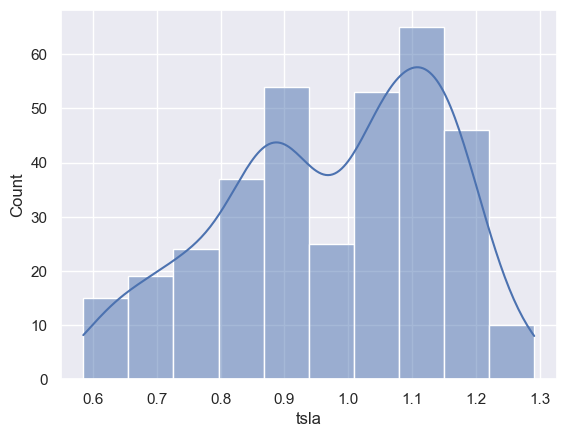

In [10]:
sns.histplot(data=norm, x=norm['tsla'], kde=True)

### Rolling Statistics

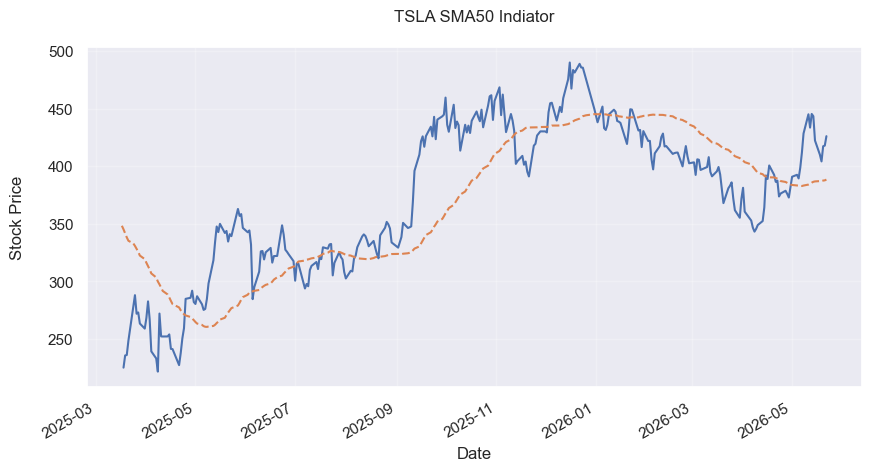

In [11]:
rollingmean = df.tsla.rolling(50).mean()
rollingstd = df.tsla.rolling(50).std() *2
fig, ax = plt.subplots(figsize=(10,5))
df.iloc[50:]['tsla'].plot(ax=ax)
ax.set_title('TSLA SMA50 Indiator\n')
ax.set_xlabel('Data')
ax.set_ylabel('Stock Price\n')
rollingmean.plot(ax=ax, linestyle='--')
plt.grid(alpha=0.25)

### Simple Moving Average (SMA)
The 50-day SMA is a trend-following indicator. It smooths out short-term price noise to reveal the underlying long-term direction of the stock.


### Bollinger Bands

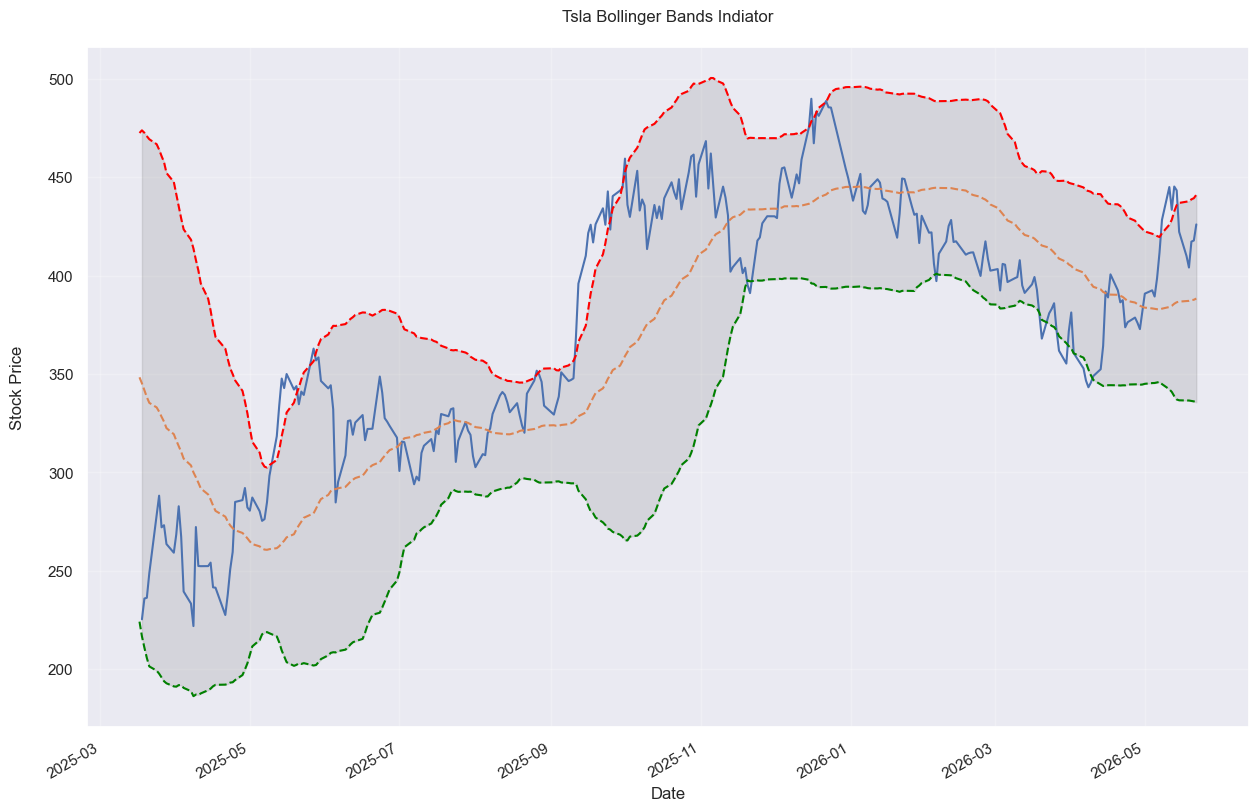

In [12]:
rollingmean = df.tsla.rolling(50).mean()
rollingstd = df.tsla.rolling(50).std() *2
fig, ax = plt.subplots(figsize=(15,10))
df.iloc[50:]['tsla'].plot(ax=ax)
ax.set_title('Tsla Bollinger Bands Indiator\n')
ax.set_xlabel('Data')
ax.set_ylabel('Stock Price\n')
rollingmean.plot(ax=ax, linestyle='--')
upper_band = rollingmean + rollingstd
lower_band = rollingmean - rollingstd
upper_band.plot(ax=ax, linestyle='--', label='Upper Band (+2 STD)', color='red')
lower_band.plot(ax=ax, linestyle='--', label='Lower Band (-2 STD)', color='green')
ax.fill_between(df.index[50:], upper_band.iloc[50:], lower_band.iloc[50:], alpha=0.2, color='gray')
plt.grid(alpha=0.25)

### Bollinger Bands
Bollinger Bands consist of an SMA and two lines plotted at standard deviation levels above and below it. They expand and contract based on volatility. Prices near the upper band may indicate an 'overbought' condition, while prices near the lower band may indicate 'oversold'.


### - Matrics

-daily Returns
-commuulative Returns
-sharpe Ratio

In [13]:
daily_returns = df.pct_change()
daily_returns.iloc[0,:] = 0
daily_returns.head()

,aapl,msft,tsla,gold,spy
Date,,,,,
2025-01-02,0.00,0.00,0.00,0.00,0.00
2025-01-03,-0.00,0.01,0.08,-0.01,0.01
2025-01-06,0.01,0.01,0.00,-0.00,0.01
2025-01-07,-0.01,-0.01,-0.04,0.01,-0.01
2025-01-08,0.00,0.01,0.00,0.00,0.00


### Daily Returns
Daily returns represent the percentage gain or loss from one day to the next. In finance, we typically analyze returns rather than prices because returns are stationary and comparable across different assets.


In [14]:
daily_returns.describe().T

,count,mean,std,min,25%,50%,75%,max
aapl,348.00,0.00,0.02,-0.09,-0.01,0.00,0.01,0.15
msft,348.00,0.00,0.02,-0.10,-0.01,0.00,0.01,0.10
tsla,348.00,0.00,0.04,-0.15,-0.02,0.00,0.02,0.23
gold,348.00,0.00,0.02,-0.11,-0.01,0.00,0.01,0.06
spy,348.00,0.00,0.01,-0.06,-0.00,0.00,0.01,0.11


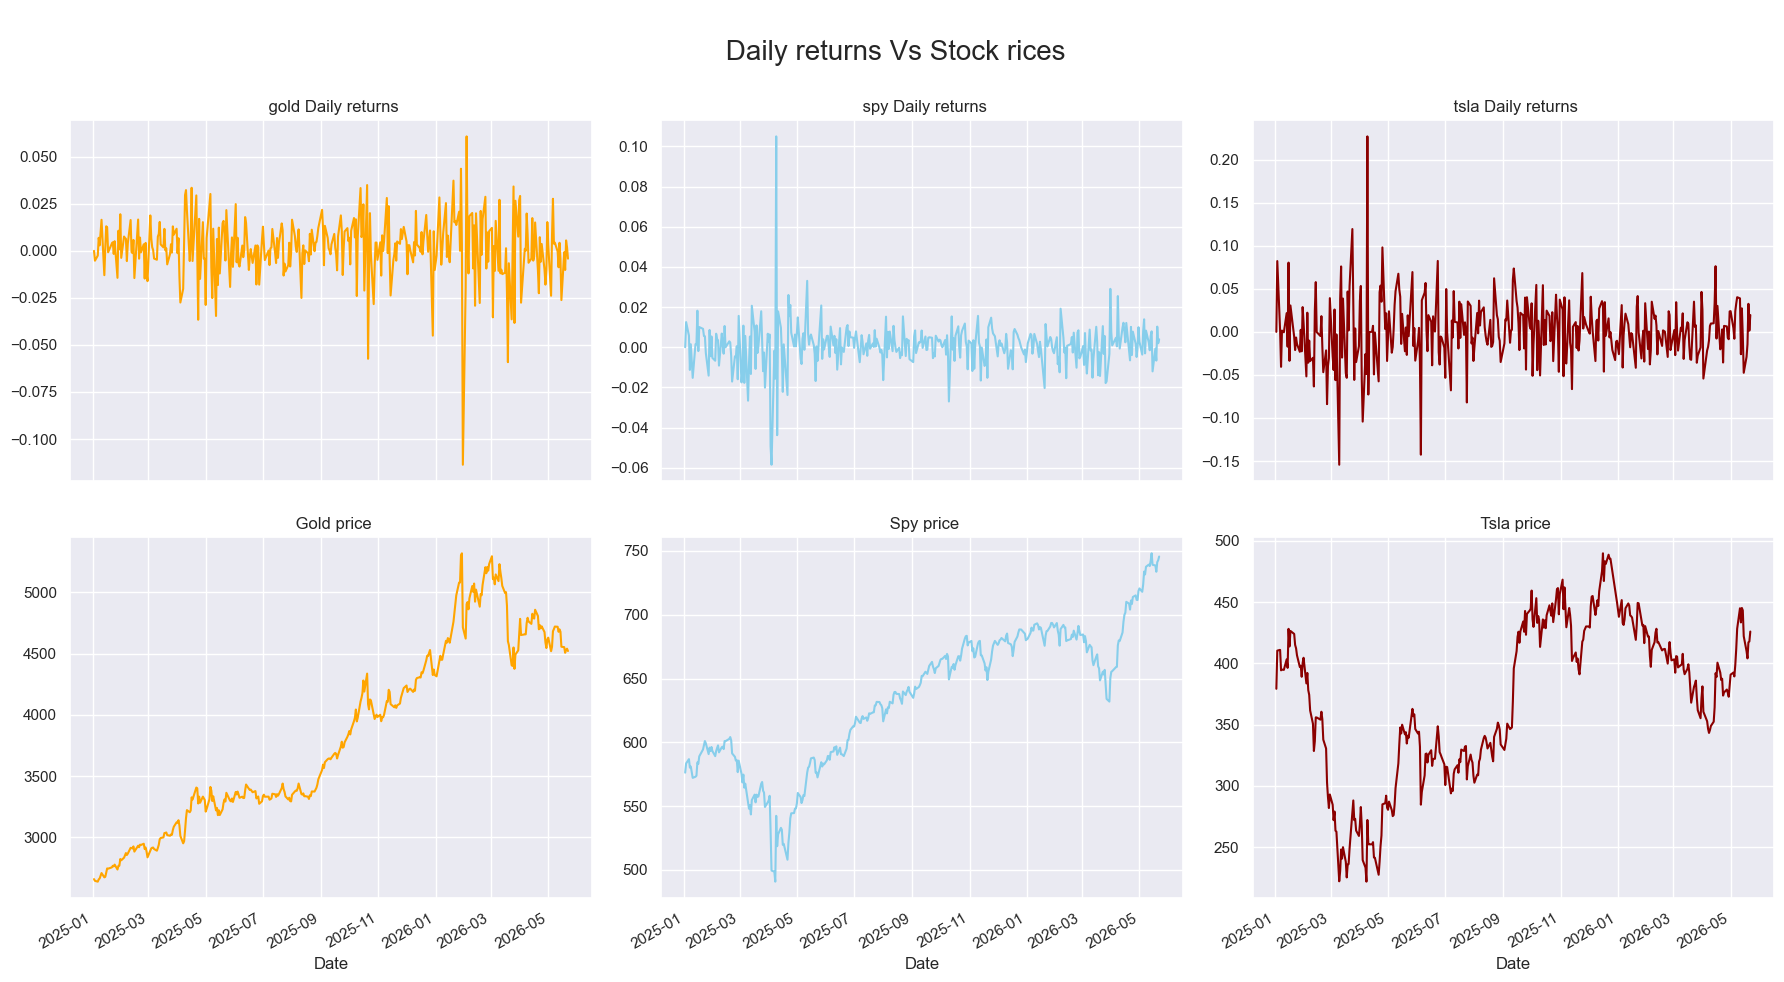

In [15]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

daily_returns.gold.plot(ax=ax[0][0], color='orange')
ax[0][0].set_title('\n gold Daily returns')

daily_returns.spy.plot(ax=ax[0][1], color='skyblue')
ax[0][1].set_title('\n spy Daily returns')

daily_returns.tsla.plot(ax=ax[0][2], color='darkred')
ax[0][2].set_title('\n tsla Daily returns')

df.gold.plot(kind='line', ax=ax[1][0], color='orange')
ax[1][0].set_title('\n Gold price')

df.spy.plot(kind='line', ax=ax[1][1], color='skyblue')
ax[1][1].set_title('\n Spy price')

df.tsla.plot(kind='line', ax=ax[1][2], color='darkred')
ax[1][2].set_title('\n Tsla price')
fig.suptitle('\n Daily returns Vs Stock rices', fontsize=20)
plt.tight_layout()

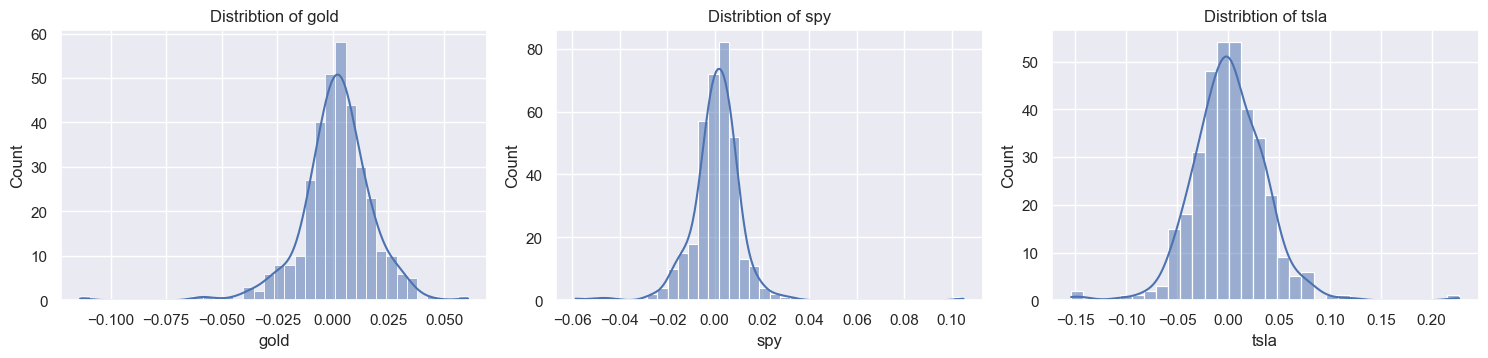

In [16]:
plt.figure(figsize=(20, 10))
for e, i in enumerate(daily_returns[['gold', 'spy', 'tsla']]):
    plt.subplot(3, 4, e+1)
    sns.histplot(daily_returns[i], kde=True)
    plt.title("Distribtion of " + i)
    plt.tight_layout()




### Distribution of Returns
We use histograms and Kernel Density Estimates (KDE) to visualize how returns are distributed. Most stock returns exhibit 'fat tails' (high kurtosis), meaning extreme price moves happen more often than a normal distribution would predict.


### cumulative returns ratio: is the profit/lose ratio of the stock on practicular period 

In [17]:
stocknames = df.columns

for stock in stocknames:
    print("cumulative return of {} is: {} %".format(stock, round(((df.iloc[-1][stock] / df.iloc[0][stock]) - 1) * 100, 2)))

cumulative return of aapl is: 27.45 %
cumulative return of msft is: 1.18 %
cumulative return of tsla is: 12.32 %
cumulative return of gold is: 70.03 %
cumulative return of spy is: 29.39 %


### Cumulative Performance
Cumulative return calculates the total profit or loss percentage since the start of the period. It helps investors understand the total 'buy and hold' outcome.


In [18]:
daily_returns.describe().T

,count,mean,std,min,25%,50%,75%,max
aapl,348.00,0.00,0.02,-0.09,-0.01,0.00,0.01,0.15
msft,348.00,0.00,0.02,-0.10,-0.01,0.00,0.01,0.10
tsla,348.00,0.00,0.04,-0.15,-0.02,0.00,0.02,0.23
gold,348.00,0.00,0.02,-0.11,-0.01,0.00,0.01,0.06
spy,348.00,0.00,0.01,-0.06,-0.00,0.00,0.01,0.11


<Axes: xlabel='Date'>

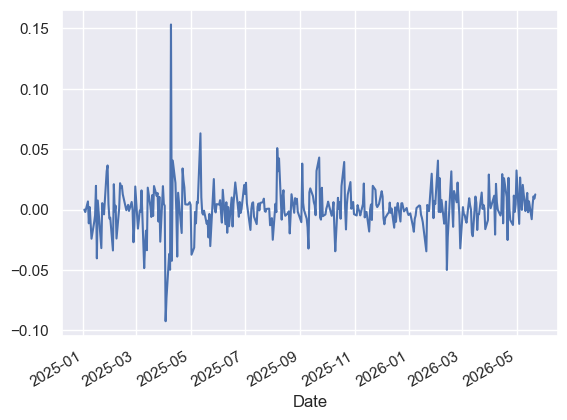

In [19]:
daily_returns.aapl.plot()

In [20]:
((daily_returns.gold[daily_returns.gold >= 0].sum()) + (daily_returns.gold[daily_returns.gold < 0].sum())) * 100

np.float64(57.65144848970942)

#### mean
### STD
### Kurtosis
### (volatiliy)risk/return

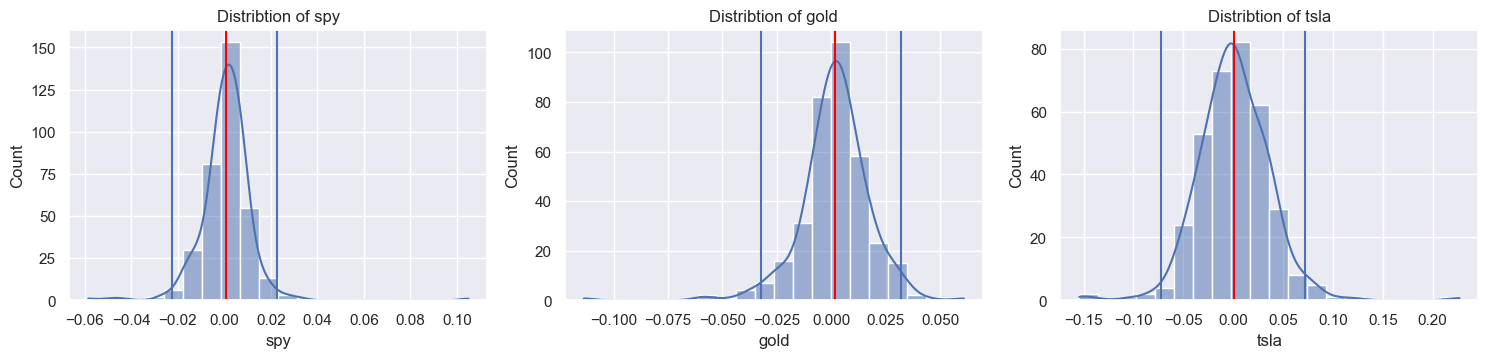

In [21]:
plt.figure(figsize=(20, 10))
for e, i in enumerate(daily_returns[['spy', 'gold', 'tsla']]):
    plt.subplot(3, 4, e+1)
    sns.histplot(daily_returns[i], kde=True, bins=20)
    plt.axvline(daily_returns[i].mean(), color="red")
    plt.axvline(daily_returns[i].std() * 2)
    plt.axvline(-daily_returns[i].std() * 2)
    plt.title("Distribtion of " + i)
    plt.tight_layout()


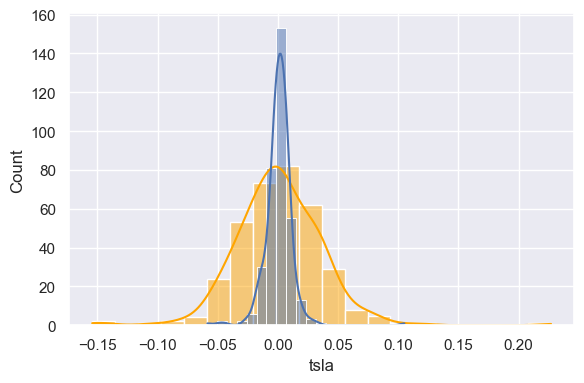

In [22]:
plt.figure(figsize=(6, 4))
sns.histplot(daily_returns.tsla, kde=True, bins=20, color="orange")
sns.histplot(daily_returns.spy, kde=True, bins=20)
plt.tight_layout()

In [23]:
print(f'the mean of Spy dr = {daily_returns.spy.mean() * 100}')
print(f'the std of Spy dr = {daily_returns.spy.std()}')
print(f'the kurtosis of Spy dr = {daily_returns.spy.kurtosis()}')

the mean of Spy dr = 0.0804201238660774
the std of Spy dr = 0.011345005139125645
the kurtosis of Spy dr = 23.30938164414578


In [24]:
print(f'the mean of tsla dr = {daily_returns.tsla.mean() * 100}')
print(f'the std of tsla dr = {daily_returns.tsla.std()}')
print(f'the kurtosis of tsla dr = {daily_returns.tsla.kurtosis()}')

the mean of tsla dr = 0.09812162377204506
the std of tsla dr = 0.03614980243791138
the kurtosis of tsla dr = 5.387601239682523


### Risk and Volatility Metrics
By calculating the mean, standard deviation, and kurtosis of daily returns, we quantify the risk/reward profile. Higher standard deviation means higher volatility (risk), while higher kurtosis indicates a higher probability of extreme price spikes or drops.


## linear Regression model

[[1.         0.71679129]
 [0.71679129 1.        ]]


<Axes: >

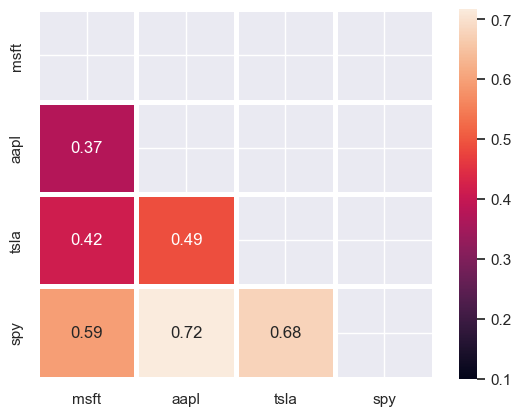

In [25]:
daily_returns = daily_returns[['msft', 'aapl', 'tsla', 'spy']]
print(np.corrcoef(daily_returns.spy, daily_returns.aapl))
mask = np.zeros_like(daily_returns.corr())
mask[np.triu_indices_from(mask)] = True
mask
sns.heatmap(daily_returns.corr(), annot=True, vmin=0.1, mask=mask, linewidths=2.5)

<Axes: xlabel='tsla', ylabel='spy'>

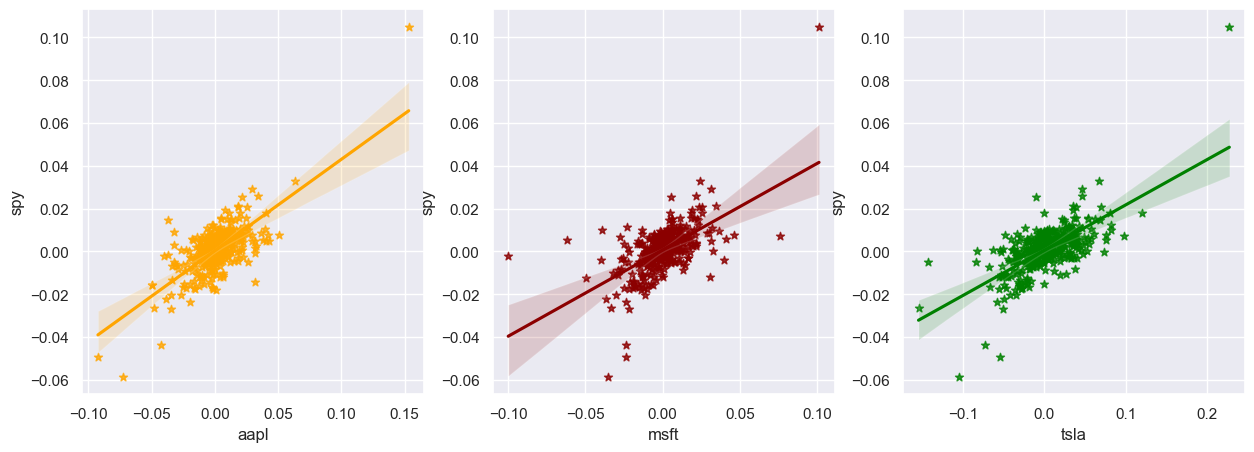

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.regplot(data=daily_returns, x=daily_returns.aapl, y=daily_returns.spy, scatter=True, marker="*", ax=ax[0], color="orange")
sns.regplot(data=daily_returns, x=daily_returns.msft, y=daily_returns.spy, scatter=True, marker="*", ax=ax[1], color="darkred")
sns.regplot(data=daily_returns, x=daily_returns.tsla, y=daily_returns.spy, scatter=True, marker="*", ax=ax[2], color="green")

### Regression and Correlation
Correlation matrices and regression plots (scatter plots with a line of best fit) show how stocks move in relation to one another and to the market (SPY). A positive correlation indicates that the assets tend to move in the same direction.


<Axes: xlabel='msft', ylabel='aapl'>

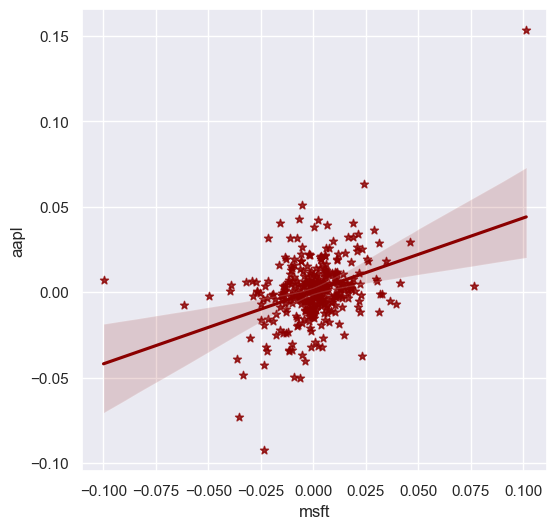

In [27]:
plt.figure(figsize=(6, 6))
sns.regplot(data=daily_returns, x=daily_returns.msft, y=daily_returns.aapl, scatter=True, marker="*", color="darkred")


In [28]:
ml = daily_returns.copy()
ml['intercept'] = 1
lm = sm.OLS(ml.spy, ml[['intercept', 'aapl']])
res = lm.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     365.6
Date:                Mon, 25 May 2026   Prob (F-statistic):           3.95e-56
Time:                        17:30:16   Log-Likelihood:                 1190.9
No. Observations:                 348   AIC:                            -2378.
Df Residuals:                     346   BIC:                            -2370.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0004      0.000      1.012      0.312      -0.000       0.001
aapl           0.4263      0.022     19.121      0.000       0.382       0.470
==============================================================================
Omnibus:                       24.808   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               88.099
Skew:                           0.084   Prob(JB):                     7.41e-20
Kurtosis:                       5.459   Cond. No.                         52.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [29]:
ml = daily_returns.copy()
ml['intercept'] = 1
lm = sm.OLS(ml.spy, ml[['intercept', 'msft']])
res = lm.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     189.0
Date:                Mon, 25 May 2026   Prob (F-statistic):           1.30e-34
Time:                        17:30:16   Log-Likelihood:                 1141.2
No. Observations:                 348   AIC:                            -2278.
Df Residuals:                     346   BIC:                            -2271.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0007      0.000      1.499      0.135      -0.000       0.002
msft           0.4037      0.029     13.746      0.000       0.346       0.461
==============================================================================
Omnibus:                       85.061   Durbin-Watson:                   2.222
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1425.924
Skew:                           0.477   Prob(JB):                    2.32e-310
Kurtosis:                      12.871   Cond. No.                         60.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Capital Asset Pricing Model (CAPM) - Beta
The OLS (Ordinary Least Squares) regression output gives us the 'Beta' coefficient. A Beta of 1.0 means the stock moves with the market. A Beta > 1.0 (like Tesla often is) means the stock is more volatile than the market, while a Beta < 1.0 means it is less sensitive to market swings.


In [30]:
ml = daily_returns.copy()
ml['intercept'] = 1
lm = sm.OLS(ml.spy, ml[['intercept', 'tsla']])
res = lm.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     291.0
Date:                Mon, 25 May 2026   Prob (F-statistic):           8.90e-48
Time:                        17:30:16   Log-Likelihood:                 1171.6
No. Observations:                 348   AIC:                            -2339.
Df Residuals:                     346   BIC:                            -2331.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0006      0.000      1.327      0.185      -0.000       0.001
tsla           0.2121      0.012     17.058      0.000       0.188       0.237
==============================================================================
Omnibus:                       71.432   Durbin-Watson:                   2.063
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              842.627
Skew:                           0.414   Prob(JB):                    1.06e-183
Kurtosis:                      10.578   Cond. No.                         27.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
slop , intercept, coef, p, std_err = stats.linregress(daily_returns.aapl, daily_returns.spy)
print(f"AAPL/SPY\nbeta slop = {slop}\nalpha (intercept) = {intercept}\nR-squared = {coef**2}\npvalue = {p}")
print("===============================================================")
slop , intercept, coef, p, std_err = stats.linregress(daily_returns.msft, daily_returns.spy)
print(f"MSFT/SPY\nbeta slop = {slop}\nalpha (intercept) = {intercept}\nR-squared = {coef**2}\npvalue = {p}")
print("===============================================================")
slop , intercept, coef, p, std_err = stats.linregress(daily_returns.tsla, daily_returns.spy)
print(f"TSLA/SPY\nbeta slop = {slop}\nalpha (intercept) = {intercept}\nR-squared = {coef**2}\npvalue = {p}")

AAPL/SPY
beta slop = 0.4262703931379659
alpha (intercept) = 0.0004304220806213161
R-squared = 0.5137897567285509
pvalue = 3.9454123288747944e-56
MSFT/SPY
beta slop = 0.40371115510927214
alpha (intercept) = 0.0007343979062302134
R-squared = 0.35322982486711346
pvalue = 1.3048210744273853e-34
TSLA/SPY
beta slop = 0.21210968066360594
alpha (intercept) = 0.0005960757758159444
R-squared = 0.456797210013843
pvalue = 8.89568600065846e-48
